# Visualize inversion results

Use this notebook to visualize some standard inversion results.

See `utils.py` for the code to generate plots and count observations in the region of interest (imported below).

Notebook can be accessed via AWS following these instructions: https://docs.aws.amazon.com/dlami/latest/devguide/setup-jupyter.html)

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import yaml
import pickle as pickle
import pandas as pd
import xesmf as xe
import cartopy.crs as ccrs
import colorcet as cc

from utils import plot_field, load_obj, sum_total_emissions, count_obs_in_mask

import warnings
import datetime
import re

warnings.filterwarnings("ignore", category=FutureWarning)

## Setup

In [ ]:
# Read the configuration file
config = yaml.load(
    open("./integrated_methane_inversion/config.own.yml"), Loader=yaml.FullLoader
)

In [ ]:
# Open the state vector file
state_vector_filepath = (
    "./integrated_methane_inversion/imi_output_Texas_dir_2018/Test_IMI/StateVector.nc"
)
state_vector = xr.load_dataset(state_vector_filepath)
state_vector_labels = state_vector["StateVector"]

# Identify the last element of the region of interest
last_ROI_element = int(
    np.nanmax(state_vector_labels.values) - config["nBufferClusters"]
)

# Define mask for region of interest
mask = state_vector_labels <= last_ROI_element

In [4]:
# Set latitude/longitude bounds for plots

# Trim 1-2.5 degrees to remove GEOS-Chem buffer zone
if config["Res"] == "0.25x0.3125":
    degx = 4 * 0.3125
    degy = 4 * 0.25
elif config["Res"] == "0.5x0.625":
    degx = 4 * 0.625
    degy = 4 * 0.5

lon_bounds = [
    np.min(state_vector.lon.values) + degx,
    np.max(state_vector.lon.values) - degx,
]
lat_bounds = [
    np.min(state_vector.lat.values) + degy,
    np.max(state_vector.lat.values) - degy,
]

In [5]:
# state_vector,
state_vector_labels.shape

(33, 34)

In [6]:
lon_bounds, lat_bounds, degx, degy

([-106.25, -90.625], [25.0, 37.0], 2.5, 2.0)

## State vector

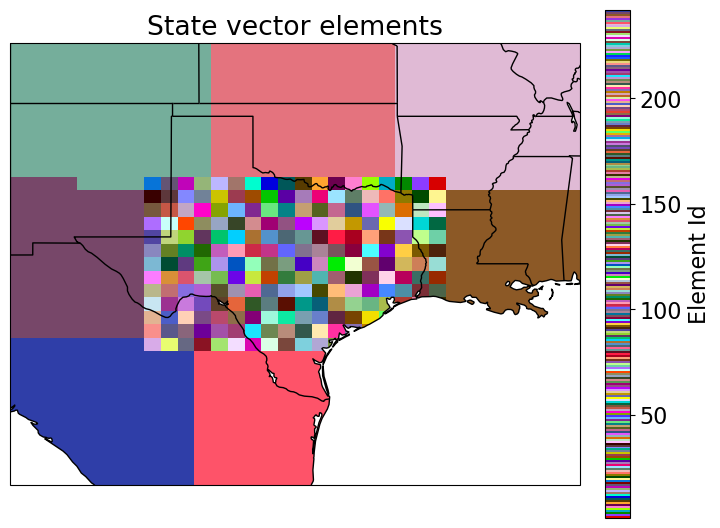

In [7]:
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

# oceans_50m = cartopy.feature.NaturalEarthFeature("physical", "ocean", "50m")
# lakes_50m = cartopy.feature.NaturalEarthFeature("physical", "lakes", "50m")
# states_provinces_50m = cartopy.feature.NaturalEarthFeature("cultural", "admin_1_states_provinces_lines", "50m")
# ax.add_feature(cartopy.feature.BORDERS, facecolor="none")
# ax.add_feature(oceans_50m, facecolor=[1, 1, 1], edgecolor="black")
# ax.add_feature(lakes_50m, facecolor=[1, 1, 1], edgecolor="black")
# ax.add_feature(states_provinces_50m, facecolor="none", edgecolor="black")
# ax.set_title('State vector elements')
# state_vector_labels.plot.pcolormesh(cmap=cc.cm.glasbey,levels=None,ax=ax,cbar_kwargs={"label": 'Element Id', "fraction": 0.041, "pad": 0.04})
# plt.savefig('test.png')

plot_field(
    ax,
    state_vector_labels,
    cmap=cc.cm.glasbey,
    title="State vector elements",
    cbar_label="Element Id",
)

## Prior & Posterior emission

In [ ]:
def plot_emis(
    year, month, prior_path, results_pth, state_vector_labels, last_ROI_element
):
    # Prior emissions
    prior = xr.load_dataset(prior_pth)["EmisCH4_Total"].isel(time=0)
    # Optimized scale factors
    scale = xr.load_dataset(results_pth)["ScaleFactor"]
    # Posterior emissions
    posterior = prior * scale

    # S_post_grid = xr.load_dataset(results_pth)['S_post']
    A_grid = xr.load_dataset(results_pth)["A"]
    avkern_ROI = A_grid.where(state_vector_labels <= last_ROI_element)

    # PLOT Scale Factors
    fig = plt.figure(figsize=(8, 8))
    plt.rcParams.update({"font.size": 16})
    ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

    plot_field(
        ax,
        scale,
        cmap="RdBu_r",
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        vmin=0,
        vmax=2,
        title="Scale factors " + str(year) + str(month).zfill(2),
        cbar_label="Scale factor",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
    )

    plt.savefig("./sf_vis_month/" + str(year) + str(month).zfill(2) + ".jpg")

    # PLOT PRIOR
    fig = plt.figure(figsize=(8, 8))
    plt.rcParams.update({"font.size": 16})
    ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
    prior_kgkm2h = prior * (1000**2) * 60 * 60  # Units kg/km2/h
    plot_field(
        ax,
        prior_kgkm2h,
        cmap=cc.cm.linear_kryw_5_100_c67_r,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        vmin=0,
        vmax=20,
        title="Prior " + str(year) + str(month).zfill(2) + " emissions",
        cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
        #            mask=mask,
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
    )
    plt.savefig("./prior_vis_month/" + str(year) + str(month).zfill(2) + ".jpg")

    # PLOT POSTERIOR
    fig = plt.figure(figsize=(8, 8))
    plt.rcParams.update({"font.size": 16})
    ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

    posterior_kgkm2h = posterior * (1000**2) * 60 * 60  # Units kg/km2/h

    plot_field(
        ax,
        posterior_kgkm2h,
        cmap=cc.cm.linear_kryw_5_100_c67_r,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        vmin=0,
        vmax=20,
        title="Posterior " + str(year) + str(month).zfill(2) + " emissions",
        cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
        #            mask=mask,
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
    )
    plt.savefig("./post_vis_month/" + str(year) + str(month).zfill(2) + ".jpg")

    # PLOT Averaging Kernel Sensitivities
    fig = plt.figure(figsize=(8, 8))
    plt.rcParams.update({"font.size": 16})
    ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

    plot_field(
        ax,
        avkern_ROI,
        cmap=cc.cm.CET_L19,
        lon_bounds=lon_bounds,
        lat_bounds=lat_bounds,
        title="Averaging kernel sensitivities " + str(year) + str(month).zfill(2),
        cbar_label="Sensitivity",
        only_ROI=True,
        state_vector_labels=state_vector_labels,
        last_ROI_element=last_ROI_element,
    )
    plt.savefig("./k_vis_month/" + str(year) + str(month).zfill(2) + ".jpg")

    return prior, posterior

In [ ]:
pd_emi = pd.DataFrame(columns=["date", "prior", "posterior", "DOFS"])
dates, priors, posteriors, dofs = [], [], [], []

for year in [2018, 2019, 2020, 2021, 2022, 2023]:
    if year == 2018:
        months = [5, 6, 7, 8, 9, 10, 11, 12]
    elif year == 2023:
        months = [1, 2, 3, 4]
    else:
        months = range(1, 13)
    for month in months:
        if year == 2023 and month == 4:
            year_month = str(year) + str(month - 1).zfill(2) + "01"
        else:
            year_month = str(year) + str(month).zfill(2) + "01"
        if month != 12:
            prior_pth = f'./jacobian_runs_Texas_{str(year)}/{config["RunName"]}_0000/OutputDir/HEMCO_diagnostics.{year_month}0000.nc'
        else:
            prior_pth = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year+1)}/{config["RunName"]}/spinup_run/OutputDir/HEMCO_diagnostics.{year_month}0000.nc'
        results_pth = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/res/gridded_posterior_{str(month)}.nc'
        satdat_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_converted'
        inversion_result_path = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/res/inversion_result_{str(month)}.nc'
        posterior_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_converted_posterior'
        visualization_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_visualization'
        posterior_viz_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_visualization_posterior'

        prior, posterior = plot_emis(
            year, month, prior_pth, results_pth, state_vector_labels, last_ROI_element
        )

        # VALUE
        areas = xr.load_dataset(prior_pth)["AREA"]
        total_prior_emissions = sum_total_emissions(prior, areas, mask)
        total_posterior_emissions = sum_total_emissions(posterior, areas, mask)

        # ungridded inversion result is used to calculate DOFS using the trace of the averaging kernel
        A_ROI = xr.load_dataset(inversion_result_path)["A"].values[
            :last_ROI_element, :last_ROI_element
        ]
        DOFS = np.trace(A_ROI)

        print("DOFS =", DOFS)
        print("Prior     emissions :", total_prior_emissions, "Tg/y")
        print("Posterior emissions :", total_posterior_emissions, "Tg/y")

        dates.append(str(year) + str(month).zfill(2))
        priors.append(total_prior_emissions)
        posteriors.append(total_posterior_emissions)
        dofs.append(DOFS)

    # YEAR TOTAL
    results_pth = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/res/gridded_posterior_T.nc'
    inversion_result_path = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/res/inversion_result_T.nc'
    prior, posterior = plot_emis(
        year, month, prior_pth, results_pth, state_vector_labels, last_ROI_element
    )
    areas = xr.load_dataset(prior_pth)["AREA"]
    total_prior_emissions = sum_total_emissions(prior, areas, mask)
    total_posterior_emissions = sum_total_emissions(posterior, areas, mask)
    A_ROI = xr.load_dataset(inversion_result_path)["A"].values[
        :last_ROI_element, :last_ROI_element
    ]
    DOFS = np.trace(A_ROI)
    print("Prior     emissions :", total_prior_emissions, "Tg/y")
    print("Posterior emissions :", total_posterior_emissions, "Tg/y")
    print("DOFS =", DOFS)
    dates.append(str(year))
    priors.append(total_prior_emissions)
    posteriors.append(total_posterior_emissions)
    dofs.append(DOFS)
pd_emi["date"], pd_emi["prior"], pd_emi["posterior"], pd_emi["DOFS"] = (
    dates,
    priors,
    posteriors,
    dofs,
)
pd_emi.to_csv("emissions_month.csv", index=False)

## Prior & Posterior concentration

### Comparison at 0.1 x 0.1 resolution & Comparison at 0.25 x 0.3125 resolution

In [11]:
# Get observed and GEOS-Chem-simulated TROPOMI columns
days = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]


def aggregate_data_month(data_dir, data_posterior, year, month):
    files = np.sort(os.listdir(data_dir))
    lat = np.array([])
    lon = np.array([])
    tropomi = np.array([])
    geos_prior = np.array([])
    geos_posterior = np.array([])
    observation_count = np.array([])

    # Reformat start and end days for datetime in configuration
    start = f"{str(year)}-{str(month)}-01 00:00:00"
    end = f"{str(year)}-{str(month)}-{str(days[month-1])} 23:59:59"
    gc_startdate = np.datetime64(datetime.datetime.strptime(start, "%Y-%m-%d %H:%M:%S"))
    gc_enddate = np.datetime64(
        datetime.datetime.strptime(end, "%Y-%m-%d %H:%M:%S")
        - datetime.timedelta(days=1)
    )

    sel_files = []
    for index in range(len(files)):
        filename = files[index]
        shortname = re.split("\/", filename)[-1]
        shortname = re.split("\.", shortname)[0]
        strdate = re.split("\.|_+|T", shortname)[4]
        strdate = datetime.datetime.strptime(strdate, "%Y%m%d")
        if (strdate >= gc_startdate) and (strdate <= gc_enddate):
            sel_files.append(filename)
    sel_files.sort()

    for f in sel_files:
        # Get paths
        pth = os.path.join(data_dir, f)
        pth_posterior = os.path.join(data_posterior, f)
        # Load TROPOMI/GEOS-Chem and Jacobian matrix data from the .pkl file
        obj = load_obj(pth)
        obj_posterior = load_obj(pth_posterior)
        # If there aren't any TROPOMI observations on this day, skip
        if obj["obs_GC"].shape[0] == 0:
            continue
        # Otherwise, grab the TROPOMI/GEOS-Chem data
        obs_GC = obj["obs_GC"]
        obs_GC_posterior = obj_posterior["obs_GC"]
        # Only consider data within latitude and longitude bounds
        ind = np.where(
            (obs_GC[:, 2] >= lon_bounds[0])
            & (obs_GC[:, 2] <= lon_bounds[1])
            & (obs_GC[:, 3] >= lat_bounds[0])
            & (obs_GC[:, 3] <= lat_bounds[1])
        )
        if len(ind[0]) == 0:  # Skip if no data in bounds
            continue
        obs_GC = obs_GC[ind[0], :]  # TROPOMI and GEOS-Chem data within bounds
        obs_GC_posterior = obs_GC_posterior[ind[0], :]
        # Record lat, lon, tropomi ch4, and geos ch4
        lat = np.concatenate((lat, obs_GC[:, 3]))
        lon = np.concatenate((lon, obs_GC[:, 2]))
        tropomi = np.concatenate((tropomi, obs_GC[:, 0]))
        geos_prior = np.concatenate((geos_prior, obs_GC[:, 1]))
        observation_count = np.concatenate((observation_count, obs_GC[:, 4]))
        geos_posterior = np.concatenate((geos_posterior, obs_GC_posterior[:, 1]))

    df = pd.DataFrame()
    df["lat"] = lat
    df["lon"] = lon
    df["tropomi"] = tropomi
    df["geos_prior"] = geos_prior
    df["geos_posterior"] = geos_posterior
    df["diff_tropomi_prior"] = geos_prior - tropomi
    df["diff_tropomi_posterior"] = geos_posterior - tropomi
    df["observation_count"] = observation_count

    return df

In [ ]:
err_df = pd.DataFrame(
    columns=["dates", "bias_prior", "bias_posterior", "RMSE_prior", "RMSE_posterior"]
)
dates, bias_prior, bias_post, rmse_prior, rmse_post = [], [], [], [], []
for year in [2018, 2019, 2020, 2021, 2022, 2023]:
    if year == 2018:
        months = [5, 6, 7, 8, 9, 10, 11, 12]
    elif year == 2023:
        months = [1, 2, 3, 4]
    else:
        months = range(1, 13)
    for month in months:
        if year == 2023 and month == 4:
            year_month = str(year) + str(month - 1).zfill(2) + "01"
        else:
            year_month = str(year) + str(month).zfill(2) + "01"
        if month != 12:
            prior_pth = f'./jacobian_runs_Texas_{str(year)}/{config["RunName"]}_0000/OutputDir/HEMCO_diagnostics.{year_month}0000.nc'
        else:
            prior_pth = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year+1)}/{config["RunName"]}/spinup_run/OutputDir/HEMCO_diagnostics.{year_month}0000.nc'
        results_pth = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/res/gridded_posterior_{str(month)}.nc'
        satdat_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_converted'
        inversion_result_path = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/res/inversion_result_{str(month)}.nc'
        posterior_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_converted_posterior'
        visualization_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_visualization'
        posterior_viz_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_visualization_posterior'

        superobs_df = aggregate_data_month(satdat_dir, posterior_dir, year, month)
        visualization_df = aggregate_data_month(
            visualization_dir, posterior_viz_dir, year, month
        )
        n_obs = len(superobs_df["tropomi"])

        print(
            f'Found {n_obs} super-observations in the domain, representing {np.sum(superobs_df["observation_count"]).round(0)} TROPOMI observations.'
        )

        # Print some error statistics
        print(
            "Bias in prior     :",
            np.round(
                np.average(
                    superobs_df["diff_tropomi_prior"],
                    weights=superobs_df["observation_count"],
                ),
                2,
            ),
            "ppb",
        )
        print(
            "Bias in posterior :",
            np.round(
                np.average(
                    superobs_df["diff_tropomi_posterior"],
                    weights=superobs_df["observation_count"],
                ),
                2,
            ),
            "ppb",
        )
        print(
            "RMSE prior        :",
            np.round(
                np.sqrt(
                    np.average(
                        superobs_df["diff_tropomi_prior"] ** 2,
                        weights=superobs_df["observation_count"],
                    )
                ),
                2,
            ),
            "ppb",
        )
        print(
            "RMSE posterior    :",
            np.round(
                np.sqrt(
                    np.average(
                        superobs_df["diff_tropomi_posterior"] ** 2,
                        weights=superobs_df["observation_count"],
                    )
                ),
                2,
            ),
            "ppb",
        )

        bias_prior.append(
            np.round(
                np.average(
                    superobs_df["diff_tropomi_prior"],
                    weights=superobs_df["observation_count"],
                ),
                2,
            )
        )
        bias_post.append(
            np.round(
                np.average(
                    superobs_df["diff_tropomi_posterior"],
                    weights=superobs_df["observation_count"],
                ),
                2,
            )
        )
        rmse_prior.append(
            np.round(
                np.sqrt(
                    np.average(
                        superobs_df["diff_tropomi_prior"] ** 2,
                        weights=superobs_df["observation_count"],
                    )
                ),
                2,
            )
        )
        rmse_post.append(
            np.round(
                np.sqrt(
                    np.average(
                        superobs_df["diff_tropomi_posterior"] ** 2,
                        weights=superobs_df["observation_count"],
                    )
                ),
                2,
            )
        )
        dates.append(str(year) + str(month).zfill(2))

        print(
            "Found",
            count_obs_in_mask(mask, superobs_df),
            "super-observations within the region of interest",
        )

        # Simple averaging scheme to grid the XCH4 data at 0.1 x 0.1 resolution
        df_copy = visualization_df.copy()  # save for later
        visualization_df["lat"] = np.round(visualization_df["lat"], 1)
        visualization_df["lon"] = np.round(visualization_df["lon"], 1)
        visualization_df = visualization_df.groupby(["lat", "lon"]).mean()
        # ds = visualization_df.to_xarray()
        ds = xr.Dataset.from_dataframe(visualization_df)

        # PLOT
        fig = plt.figure(figsize=(30, 30))
        (ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9) = fig.subplots(
            3, 3, subplot_kw={"projection": ccrs.PlateCarree()}
        )

        min_value = np.array(
            [
                np.nanmin(ds["tropomi"]),
                np.nanmin(ds["geos_prior"]),
                np.nanmin(ds["geos_posterior"]),
            ]
        ).max()
        max_value = np.array(
            [
                np.nanmax(ds["tropomi"]),
                np.nanmax(ds["geos_prior"]),
                np.nanmax(ds["geos_posterior"]),
            ]
        ).min()

        # Mean TROPOMI XCH4 columns on 0.1 x 0.1 grid
        plot_field(
            ax1,
            ds["tropomi"],
            cmap="Spectral_r",
            vmin=min_value,
            vmax=max_value,
            lon_bounds=lon_bounds,
            lat_bounds=lat_bounds,
            title="TROPOMI $X_{CH4}$",
            cbar_label="Column mixing ratio (ppb)",
            #            mask=mask,
            only_ROI=False,
        )

        # Mean prior and posterior GEOS-Chem XCH4 columns on 0.1 x 0.1 grid
        plot_field(
            ax2,
            ds["geos_prior"],
            cmap="Spectral_r",
            vmin=min_value,
            vmax=max_value,
            lon_bounds=lon_bounds,
            lat_bounds=lat_bounds,
            title="GEOS-Chem $X_{CH4}$ (prior simulation)",
            cbar_label="Dry column mixing ratio (ppb)",
            only_ROI=False,
        )

        plot_field(
            ax3,
            ds["geos_posterior"],
            cmap="Spectral_r",
            vmin=min_value,
            vmax=max_value,
            lon_bounds=lon_bounds,
            lat_bounds=lat_bounds,
            title="GEOS-Chem $X_{CH4}$ (posterior simulation)",
            cbar_label="Dry column mixing ratio (ppb)",
            only_ROI=False,
        )

        plot_field(
            ax4,
            ds["diff_tropomi_prior"],
            cmap="RdBu_r",
            vmin=-np.nanmax(ds["diff_tropomi_prior"]),
            vmax=np.nanmax(ds["diff_tropomi_prior"]),
            lon_bounds=lon_bounds,
            lat_bounds=lat_bounds,
            title="Prior $-$ TROPOMI",
            cbar_label="ppb",
            only_ROI=False,
        )

        plot_field(
            ax5,
            ds["diff_tropomi_posterior"],
            cmap="RdBu_r",
            vmin=-np.nanmax(ds["diff_tropomi_posterior"]),
            vmax=np.nanmax(ds["diff_tropomi_posterior"]),
            lon_bounds=lon_bounds,
            lat_bounds=lat_bounds,
            title="Posterior $-$ TROPOMI",
            cbar_label="ppb",
            only_ROI=False,
        )

        diff = ds["geos_posterior"] - ds["geos_prior"]
        plot_field(
            ax6,
            diff,
            cmap="seismic",
            vmin=-np.nanmax(diff),
            vmax=np.nanmax(diff),
            lon_bounds=lon_bounds,
            lat_bounds=lat_bounds,
            title="$\Delta X_{CH4}$ (Posterior $-$ Prior)",
            cbar_label="ppb",
            only_ROI=False,
        )

        superobs_df.to_csv(
            "./concentration_csv_month/superobs_"
            + str(year)
            + str(month).zfill(2)
            + ".csv"
        )
        visualization_df.to_csv(
            "./concentration_csv_month/vis_" + str(year) + str(month).zfill(2) + ".csv"
        )

        # Simple averaging scheme to grid the XCH4 data at 0.1 x 0.1 resolution
        df_copy = superobs_df.copy()  # save for later
        superobs_df["lat"] = np.round(superobs_df["lat"], 1)
        superobs_df["lon"] = np.round(superobs_df["lon"], 1)
        superobs_df = superobs_df.groupby(["lat", "lon"]).mean()
        # ds = superobs_df.to_xarray()
        ds = xr.Dataset.from_dataframe(superobs_df)
        # calculate the grid bounds for .1x.1 grid
        lat_b = np.arange(ds["lat"][0] - 0.05, ds["lat"][-1] + 0.1, 0.1)
        lon_b = np.arange(ds["lon"][0] - 0.05, ds["lon"][-1] + 0.1, 0.1)
        ds = ds.assign_coords(lon_b=("lon_b", lon_b))
        ds = ds.assign_coords(lat_b=("lat_b", lat_b))
        ds["mask"] = xr.where(~np.isnan(ds["tropomi"]), 1, 0)

        # Global 0.25 x 0.3125 grid
        reference_lat_grid = np.arange(-90, 90 + 0.25, 0.25)
        reference_lon_grid = np.arange(-180, 180 + 0.3125, 0.3125)

        # Find closest reference coordinates to selected lat/lon bounds
        lat_min = reference_lat_grid[
            np.abs(reference_lat_grid - lat_bounds[0]).argmin()
        ]
        lon_min = reference_lon_grid[
            np.abs(reference_lon_grid - lon_bounds[0]).argmin()
        ]
        lat_max = reference_lat_grid[
            np.abs(reference_lat_grid - lat_bounds[1]).argmin()
        ]
        lon_max = reference_lon_grid[
            np.abs(reference_lon_grid - lon_bounds[1]).argmin()
        ]

        # Create an xESMF regridder object to resample the data on the grid HEMCO expects
        new_lat_grid = np.arange(lat_min, lat_max + 0.25, 0.25)
        new_lon_grid = np.arange(lon_min, lon_max + 0.3125, 0.3125)
        new_lat_b = np.arange(new_lat_grid[0] - 0.125, new_lat_grid[-1] + 0.25, 0.25)
        new_lon_b = np.arange(
            new_lon_grid[0] - 0.15625, new_lon_grid[-1] + 0.3125, 0.3125
        )
        ds_out = xr.Dataset(
            {
                "lat": (["lat"], new_lat_grid),
                "lon": (["lon"], new_lon_grid),
                "lat_b": (["lat_b"], new_lat_b),
                "lon_b": (["lon_b"], new_lon_b),
            }
        )

        # regridder = xe.Regridder(ds, ds_out, 'conservative_normed')
        regridder = xe.Regridder(ds, ds_out, method="bilinear")
        # regridder = xe.Regridder(ds, ds_out, method='conservative')

        # Regrid the data
        ds_regrid = regridder(ds)

        plot_field(
            ax7,
            ds_regrid["diff_tropomi_prior"],
            cmap="RdBu_r",
            vmin=-np.nanmax(ds_regrid["diff_tropomi_prior"]),
            vmax=np.nanmax(ds_regrid["diff_tropomi_prior"]),
            lon_bounds=lon_bounds,
            lat_bounds=lat_bounds,
            title="Prior $-$ TROPOMI",
            cbar_label="ppb",
            only_ROI=False,
        )

        plot_field(
            ax8,
            ds_regrid["diff_tropomi_posterior"],
            cmap="RdBu_r",
            vmin=-np.nanmax(ds_regrid["diff_tropomi_posterior"]),
            vmax=np.nanmax(ds_regrid["diff_tropomi_posterior"]),
            lon_bounds=lon_bounds,
            lat_bounds=lat_bounds,
            title="Posterior $-$ TROPOMI",
            cbar_label="ppb",
            only_ROI=False,
        )

        diff_regrid = ds_regrid["geos_posterior"] - ds_regrid["geos_prior"]
        plot_field(
            ax9,
            diff_regrid,
            cmap="seismic",
            vmin=-np.nanmax(diff_regrid),
            vmax=np.nanmax(diff_regrid),
            lon_bounds=lon_bounds,
            lat_bounds=lat_bounds,
            title="Posterior $-$ Prior",
            cbar_label="ppb",
            only_ROI=False,
        )
        plt.savefig(
            "./concentration_vis_month/" + str(year) + str(month).zfill(2) + ".jpg"
        )

(
    err_df["dates"],
    err_df["bias_prior"],
    err_df["bias_posterior"],
    err_df["RMSE_prior"],
    err_df["RMSE_posterior"],
) = (dates, bias_prior, bias_post, rmse_prior, rmse_post)
err_df.to_csv("errors_month.csv", index=False)

### Yearly

In [ ]:
satdat_files, posterior_files, visualization_files, posterior_viz_files = [], [], [], []
for year in [2018, 2019, 2020, 2021, 2022, 2023]:
    satdat_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_converted'
    posterior_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_converted_posterior'
    visualization_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_visualization'
    posterior_viz_dir = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/data_visualization_posterior'

    satdat_files.extend(
        [os.path.join(satdat_dir, filename) for filename in os.listdir(satdat_dir)]
    )
    posterior_files.extend(
        [
            os.path.join(posterior_dir, filename)
            for filename in os.listdir(posterior_dir)
        ]
    )
    visualization_files.extend(
        [
            os.path.join(visualization_dir, filename)
            for filename in os.listdir(visualization_dir)
        ]
    )
    posterior_viz_files.extend(
        [
            os.path.join(posterior_viz_dir, filename)
            for filename in os.listdir(posterior_viz_dir)
        ]
    )
satdat_files = np.sort(satdat_files)
posterior_files = np.sort(posterior_files)
visualization_files = np.sort(visualization_files)
posterior_viz_files = np.sort(posterior_viz_files)

In [21]:
# Get observed and GEOS-Chem-simulated TROPOMI columns
def aggregate_data_year(data_files, data_posterior):
    lat = np.array([])
    lon = np.array([])
    tropomi = np.array([])
    geos_prior = np.array([])
    geos_posterior = np.array([])
    observation_count = np.array([])

    for idx, pth in enumerate(data_files):
        # Get paths
        pth_posterior = data_posterior[idx]
        # Load TROPOMI/GEOS-Chem and Jacobian matrix data from the .pkl file
        obj = load_obj(pth)
        obj_posterior = load_obj(pth_posterior)
        # If there aren't any TROPOMI observations on this day, skip
        if obj["obs_GC"].shape[0] == 0:
            continue
        # Otherwise, grab the TROPOMI/GEOS-Chem data
        obs_GC = obj["obs_GC"]
        obs_GC_posterior = obj_posterior["obs_GC"]
        # Only consider data within latitude and longitude bounds
        ind = np.where(
            (obs_GC[:, 2] >= lon_bounds[0])
            & (obs_GC[:, 2] <= lon_bounds[1])
            & (obs_GC[:, 3] >= lat_bounds[0])
            & (obs_GC[:, 3] <= lat_bounds[1])
        )
        if len(ind[0]) == 0:  # Skip if no data in bounds
            continue
        obs_GC = obs_GC[ind[0], :]  # TROPOMI and GEOS-Chem data within bounds
        obs_GC_posterior = obs_GC_posterior[ind[0], :]
        # Record lat, lon, tropomi ch4, and geos ch4
        lat = np.concatenate((lat, obs_GC[:, 3]))
        lon = np.concatenate((lon, obs_GC[:, 2]))
        tropomi = np.concatenate((tropomi, obs_GC[:, 0]))
        geos_prior = np.concatenate((geos_prior, obs_GC[:, 1]))
        observation_count = np.concatenate((observation_count, obs_GC[:, 4]))
        geos_posterior = np.concatenate((geos_posterior, obs_GC_posterior[:, 1]))

    df = pd.DataFrame()
    df["lat"] = lat
    df["lon"] = lon
    df["tropomi"] = tropomi
    df["geos_prior"] = geos_prior
    df["geos_posterior"] = geos_posterior
    df["diff_tropomi_prior"] = geos_prior - tropomi
    df["diff_tropomi_posterior"] = geos_posterior - tropomi
    df["observation_count"] = observation_count

    return df


superobs_df = aggregate_data_year(satdat_files, posterior_files)
visualization_df = aggregate_data_year(visualization_files, posterior_viz_files)
n_obs = len(superobs_df["tropomi"])

print(
    f'Found {n_obs} super-observations in the domain, representing {np.sum(superobs_df["observation_count"]).round(0)} TROPOMI observations.'
)
superobs_df.head()

Found 396555 super-observations in the domain, representing 9574538.0 TROPOMI observations.


,lat,lon,tropomi,geos_prior,geos_posterior,diff_tropomi_prior,diff_tropomi_posterior,observation_count
0,25.966532,-105.439865,1807.663818,1832.602295,1833.512085,24.938477,25.848267,3.172097
1,26.463840,-105.320435,1835.046143,1832.236084,1833.050171,-2.810059,-1.995972,0.876364
2,26.778942,-105.248688,1838.863403,1832.485107,1833.183472,-6.378296,-5.679932,0.078135
3,35.940948,-105.276215,1818.305908,1817.875366,1817.867554,-0.430542,-0.438354,0.246437
4,25.724712,-104.628273,1845.729126,1830.173340,1830.983521,-15.555786,-14.745605,0.440324


In [22]:
# Print some error statistics
print(
    "Bias in prior     :",
    np.round(
        np.average(
            superobs_df["diff_tropomi_prior"], weights=superobs_df["observation_count"]
        ),
        2,
    ),
    "ppb",
)
print(
    "Bias in posterior :",
    np.round(
        np.average(
            superobs_df["diff_tropomi_posterior"],
            weights=superobs_df["observation_count"],
        ),
        2,
    ),
    "ppb",
)
print(
    "RMSE prior        :",
    np.round(
        np.sqrt(
            np.average(
                superobs_df["diff_tropomi_prior"] ** 2,
                weights=superobs_df["observation_count"],
            )
        ),
        2,
    ),
    "ppb",
)
print(
    "RMSE posterior    :",
    np.round(
        np.sqrt(
            np.average(
                superobs_df["diff_tropomi_posterior"] ** 2,
                weights=superobs_df["observation_count"],
            )
        ),
        2,
    ),
    "ppb",
)

Bias in prior     : -2.8 ppb
Bias in posterior : 1.8 ppb
RMSE prior        : 11.68 ppb
RMSE posterior    : 11.4 ppb


In [23]:
# Simple averaging scheme to grid the XCH4 data at 0.1 x 0.1 resolution
df_copy = visualization_df.copy()  # save for later
visualization_df["lat"] = np.round(visualization_df["lat"], 1)
visualization_df["lon"] = np.round(visualization_df["lon"], 1)
visualization_df = visualization_df.groupby(["lat", "lon"]).mean()
# ds = visualization_df.to_xarray()

In [24]:
ds = xr.Dataset.from_dataframe(visualization_df)

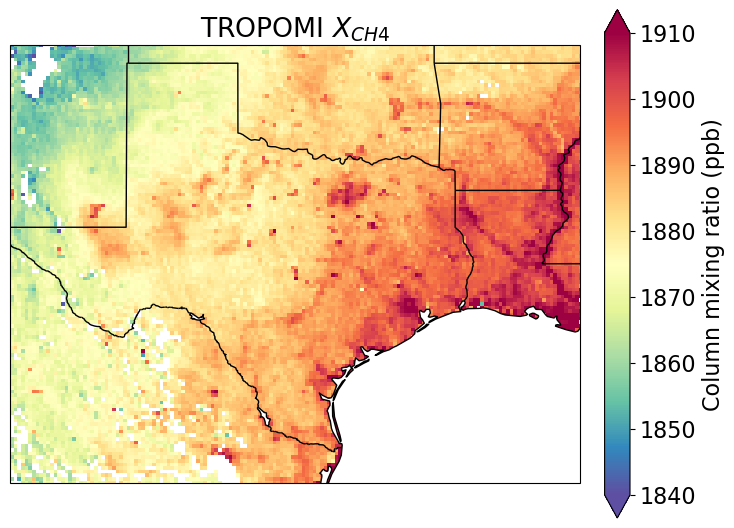

In [94]:
# Mean TROPOMI XCH4 columns on 0.1 x 0.1 grid
fig = plt.figure(figsize=(8, 8))
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax,
    ds["tropomi"],
    cmap="Spectral_r",
    vmin=1840,
    vmax=1910,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="TROPOMI $X_{CH4}$",
    cbar_label="Column mixing ratio (ppb)",
    #            mask=mask,
    only_ROI=False,
)

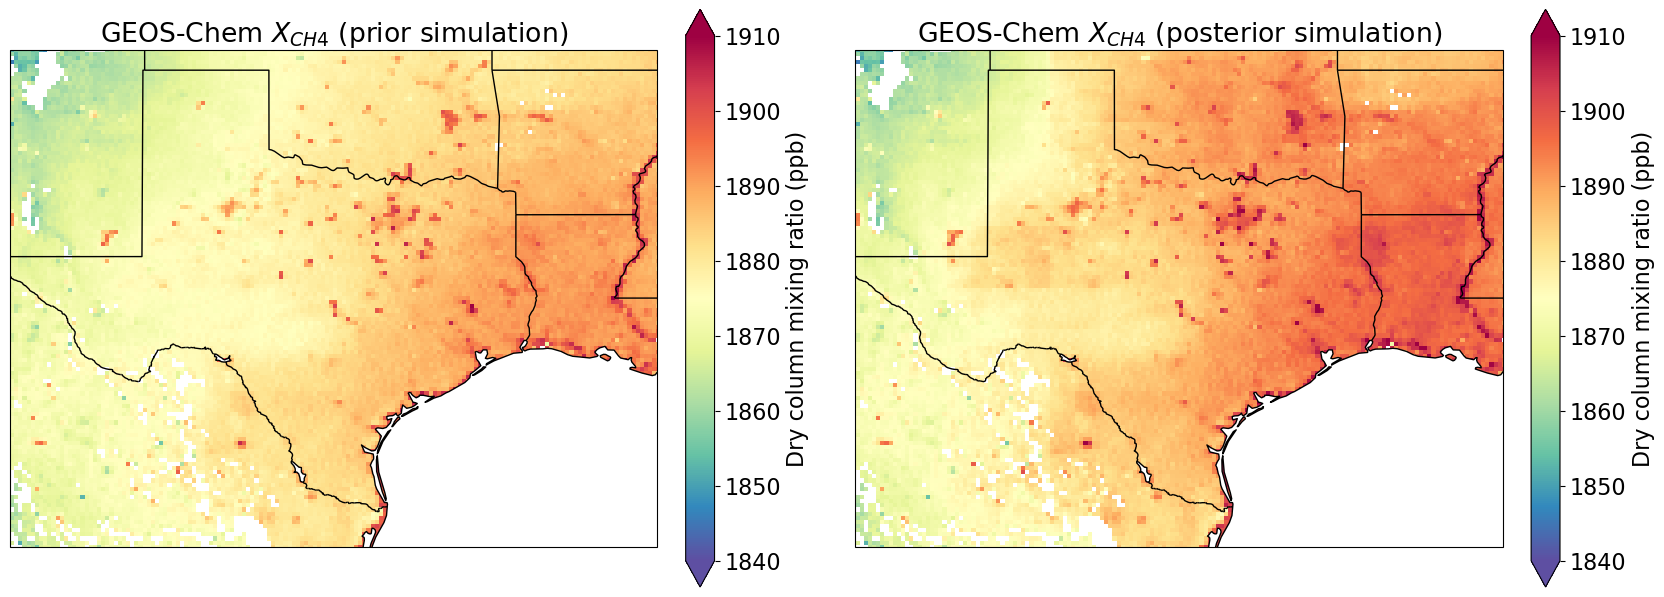

In [95]:
# Mean prior and posterior GEOS-Chem XCH4 columns on 0.1 x 0.1 grid
fig = plt.figure(figsize=(20, 8))
ax1, ax2 = fig.subplots(1, 2, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax1,
    ds["geos_prior"],
    cmap="Spectral_r",
    vmin=1840,
    vmax=1910,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="GEOS-Chem $X_{CH4}$ (prior simulation)",
    cbar_label="Dry column mixing ratio (ppb)",
    #            mask=mask,
    only_ROI=False,
)

plot_field(
    ax2,
    ds["geos_posterior"],
    cmap="Spectral_r",
    vmin=1840,
    vmax=1910,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="GEOS-Chem $X_{CH4}$ (posterior simulation)",
    cbar_label="Dry column mixing ratio (ppb)",
    #            mask=mask,
    only_ROI=False,
)

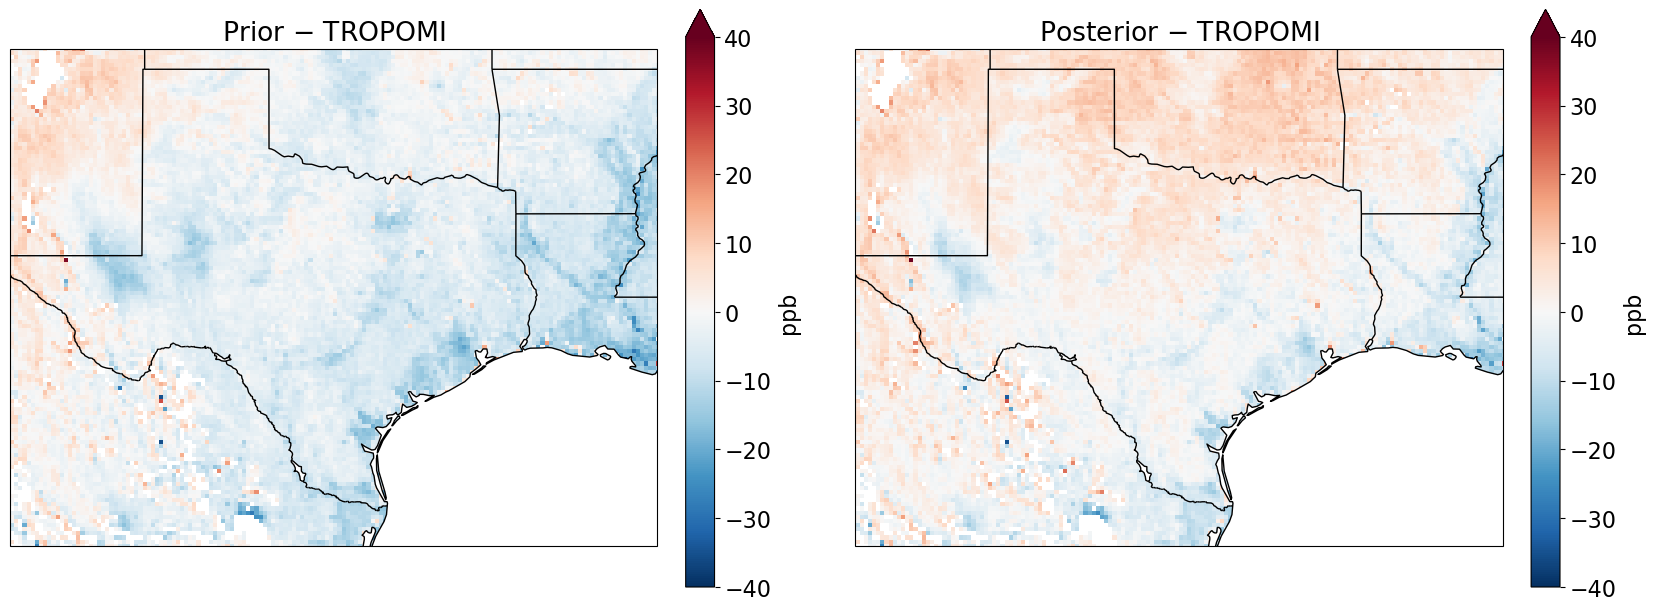

In [98]:
# Plot differences between GEOS-Chem and TROPOMI XCH4
fig = plt.figure(figsize=(20, 8))
ax1, ax2 = fig.subplots(1, 2, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax1,
    ds["diff_tropomi_prior"],
    cmap="RdBu_r",
    vmin=-40,
    vmax=40,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="Prior $-$ TROPOMI",
    cbar_label="ppb",
    #            mask=mask,
    only_ROI=False,
)

plot_field(
    ax2,
    ds["diff_tropomi_posterior"],
    cmap="RdBu_r",
    vmin=-40,
    vmax=40,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="Posterior $-$ TROPOMI",
    cbar_label="ppb",
    #            mask=mask,
    only_ROI=False,
)

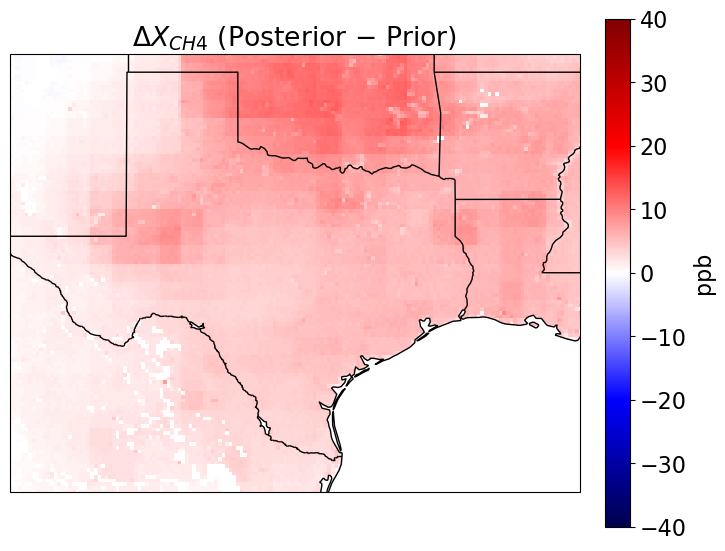

In [96]:
# Plot differences between posterior and prior simulated XCH4
fig = plt.figure(figsize=(8, 8))
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

diff = ds["geos_posterior"] - ds["geos_prior"]

plot_field(
    ax,
    diff,
    cmap="seismic",
    vmin=-40,
    vmax=40,
    #            vmin=-np.nanmax(diff),vmax=np.nanmax(diff),
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="$\Delta X_{CH4}$ (Posterior $-$ Prior)",
    cbar_label="ppb",
    #            mask=mask,
    only_ROI=False,
)

In [ ]:
for year in [2018, 2019, 2020, 2021, 2022, 2023]:
    prior_pth = f'./jacobian_runs_Texas_2020/{config["RunName"]}_0000/OutputDir/HEMCO_diagnostics.202001010000.nc'
    results_pth = f'./integrated_methane_inversion/imi_output_Texas_dir_{str(year)}/{config["RunName"]}/inversion/res/gridded_posterior_T.nc'
    if year == 2018:
        prior = xr.load_dataset(prior_pth)["EmisCH4_Total"].isel(time=0)
        scale = xr.load_dataset(results_pth)["ScaleFactor"]
        posterior = (
            xr.load_dataset(prior_pth)["EmisCH4_Total"].isel(time=0)
            * xr.load_dataset(results_pth)["ScaleFactor"]
        )
    else:
        prior += xr.load_dataset(prior_pth)["EmisCH4_Total"].isel(time=0)
        posterior += (
            xr.load_dataset(prior_pth)["EmisCH4_Total"].isel(time=0)
            * xr.load_dataset(results_pth)["ScaleFactor"]
        )
        scale += xr.load_dataset(results_pth)["ScaleFactor"]

prior = prior / 5
posterior = posterior / 5
scale = scale / 5

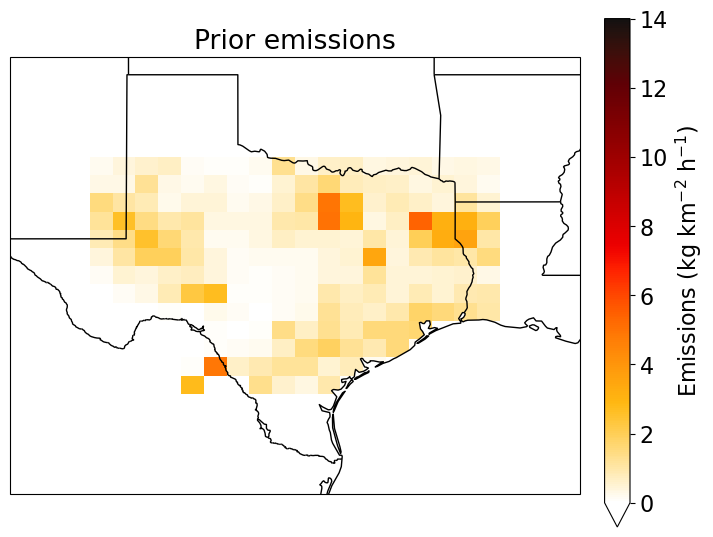

In [99]:
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

prior_kgkm2h = prior * (1000**2) * 60 * 60  # Units kg/km2/h


plot_field(
    ax,
    prior_kgkm2h,
    cmap=cc.cm.linear_kryw_5_100_c67_r,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    vmin=0,
    vmax=14,
    title="Prior emissions",
    cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
    #            mask=mask,
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
)

In [82]:
areas = xr.load_dataset(prior_pth)["AREA"]

total_prior_emissions = sum_total_emissions(prior, areas, mask)
total_posterior_emissions = sum_total_emissions(posterior, areas, mask)

print("Prior     emissions :", total_prior_emissions, "Tg/y")
print("Posterior emissions :", total_posterior_emissions, "Tg/y")

Prior     emissions : 4.977720087764932 Tg/y
Posterior emissions : 8.238162620426179 Tg/y


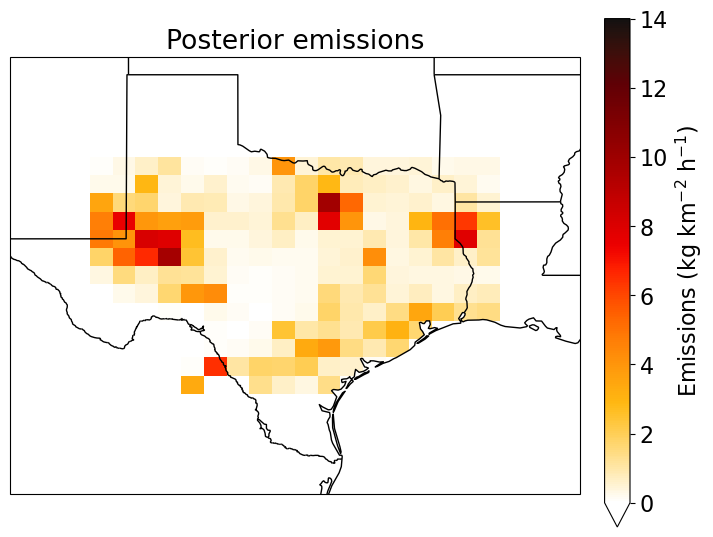

In [80]:
# Plot posterior emissions
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

posterior_kgkm2h = posterior * (1000**2) * 60 * 60  # Units kg/km2/h

plot_field(
    ax,
    posterior_kgkm2h,
    cmap=cc.cm.linear_kryw_5_100_c67_r,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    vmin=0,
    vmax=14,
    title="Posterior emissions",
    cbar_label="Emissions (kg km$^{-2}$ h$^{-1}$)",
    #            mask=mask,
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
)

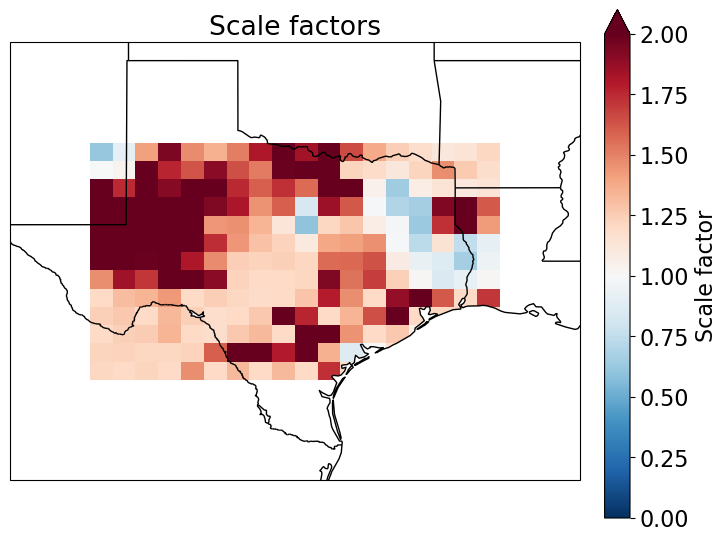

In [83]:
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax,
    scale,
    cmap="RdBu_r",
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    vmin=0,
    vmax=2,
    title="Scale factors",
    cbar_label="Scale factor",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
)

In [84]:
S_post_grid = xr.load_dataset(results_pth)["S_post"]
A_grid = xr.load_dataset(results_pth)["A"]
avkern_ROI = A_grid.where(state_vector_labels <= last_ROI_element)

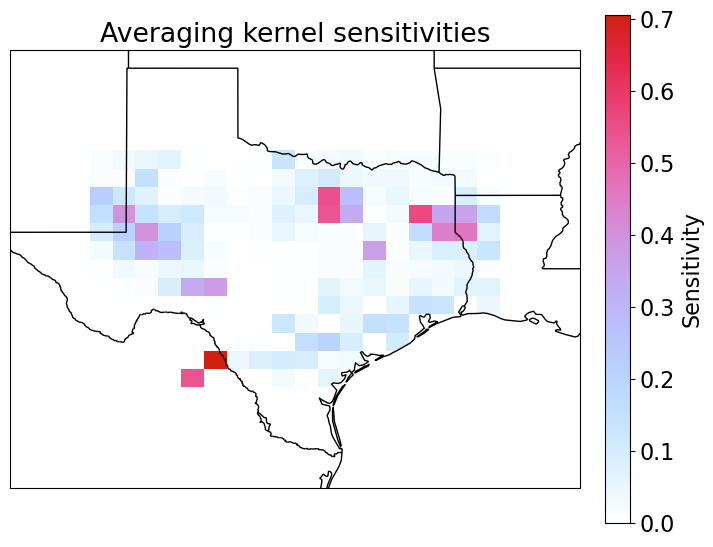

In [85]:
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({"font.size": 16})
ax = fig.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})

plot_field(
    ax,
    avkern_ROI,
    cmap=cc.cm.CET_L19,
    lon_bounds=lon_bounds,
    lat_bounds=lat_bounds,
    title="Averaging kernel sensitivities",
    cbar_label="Sensitivity",
    only_ROI=True,
    state_vector_labels=state_vector_labels,
    last_ROI_element=last_ROI_element,
)

In [86]:
# ungridded inversion result is used to calculate DOFS using the trace of the averaging kernel
A_ROI = xr.load_dataset(inversion_result_path)["A"].values[
    :last_ROI_element, :last_ROI_element
]
DOFS = np.trace(A_ROI)
print("DOFS =", DOFS)

DOFS = 23.31742


----